In [88]:
from cirq_sic import *
import matplotlib.pyplot as plt

In [89]:
def rand_states(d, n):
    states = np.random.randn(n, d) + 1j*np.random.randn(n, d)
    return states/np.linalg.norm(states, axis=1, keepdims=True)

In [178]:
d = 10
D = wh_operators(d)["D"].reshape(d**2, d, d)
phi_sic = load_sic_fiducial(d)

In [181]:
N = 100000
alpha = 3
x = rand_states(d, N)
#x = np.array([phi_sic, np.eye(d)[0], np.eye(d)[1], x[0], x[1]])
chi = abs(np.einsum("...j, ijk, ...k", x.conj(), D, x))**2/d
sic_chi = abs(np.einsum("j, ijk, ...k", phi_sic.conj(), D, x))**2/d
se = (1/(1-alpha))*np.log(np.sum(chi**alpha, axis=1)) - np.log(d)
sic_e = (1/(1-alpha))*np.log(np.sum(sic_chi**alpha, axis=1)) - np.log(d)

Text(0, 0.5, 'SIC Renyi Entropy')

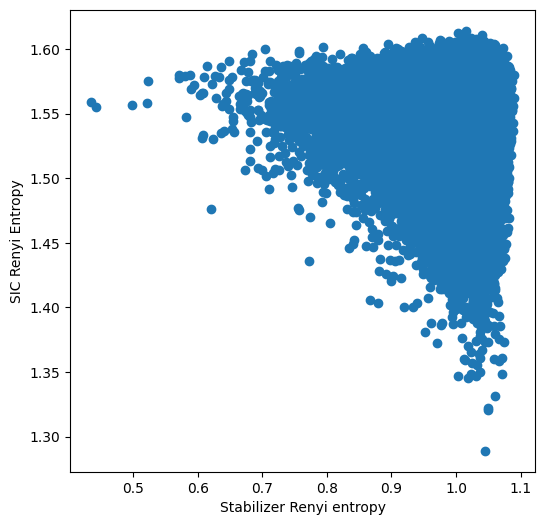

In [182]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(se, sic_e)
ax.set_xlabel("Stabilizer Renyi entropy")
ax.set_ylabel("SIC Renyi Entropy")

In [185]:
np.cov(se, sic_e)

array([[ 0.0024352442, -0.0000293057],
       [-0.0000293057,  0.0006927689]])

In [186]:
np.corrcoef(se, sic_e)

array([[ 1.          , -0.0225624946],
       [-0.0225624946,  1.          ]])

In [191]:
def binned_conditional_variance(x, y, bins=20):
    """
    Estimates Var(y | x) by binning x.
    Returns bin centers, conditional means, conditional variances, and counts.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    edges = np.linspace(np.min(x), np.max(x), bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    means = np.full(bins, np.nan)
    variances = np.full(bins, np.nan)
    counts = np.zeros(bins, dtype=int)

    for k in range(bins):
        mask = (x >= edges[k]) & (x < edges[k+1])
        if k == bins - 1:
            mask = (x >= edges[k]) & (x <= edges[k+1])

        counts[k] = np.sum(mask)

        if counts[k] >= 2:
            means[k] = np.mean(y[mask])
            variances[k] = np.var(y[mask], ddof=1)

    return centers, means, variances, counts


# Example usage:
# A and B are arrays of length N

def plot_heteroscedasticity(A, B, bins=10):
    centers_A, mean_B_given_A, var_B_given_A, counts_A = binned_conditional_variance(A, B, bins=bins)
    centers_B, mean_A_given_B, var_A_given_B, counts_B = binned_conditional_variance(B, A, bins=bins)

    plt.figure()
    plt.scatter(A, B, alpha=0.3, label="samples")
    plt.xlabel("A")
    plt.ylabel("B")
    plt.title("Scatter plot of B vs A")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(centers_A, var_B_given_A, marker="o")
    plt.xlabel("A bin center")
    plt.ylabel("Var(B | A in bin)")
    plt.title("Conditional variance of B as A varies")
    plt.show()

    plt.figure()
    plt.plot(centers_B, var_A_given_B, marker="o")
    plt.xlabel("B bin center")
    plt.ylabel("Var(A | B in bin)")
    plt.title("Conditional variance of A as B varies")
    plt.show()

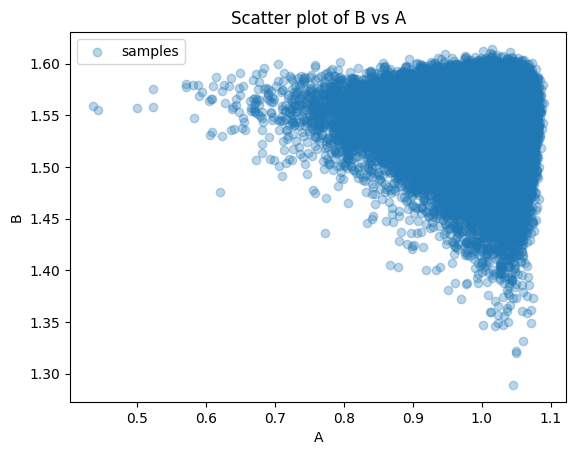

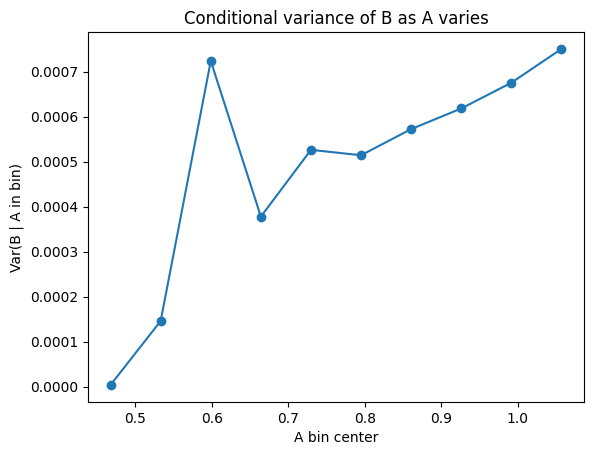

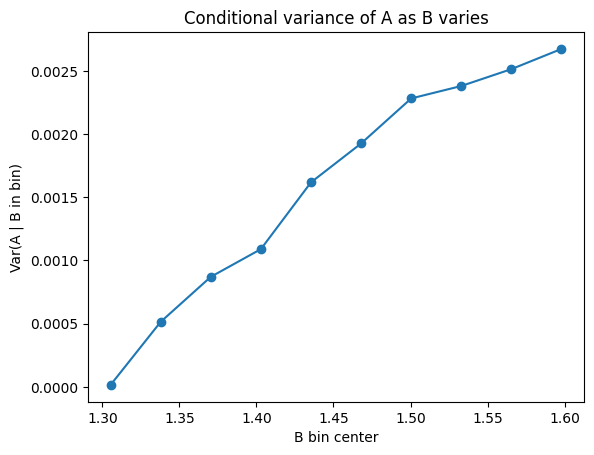

In [192]:
plot_heteroscedasticity(se, sic_e)